Shape: (4521, 17)
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total

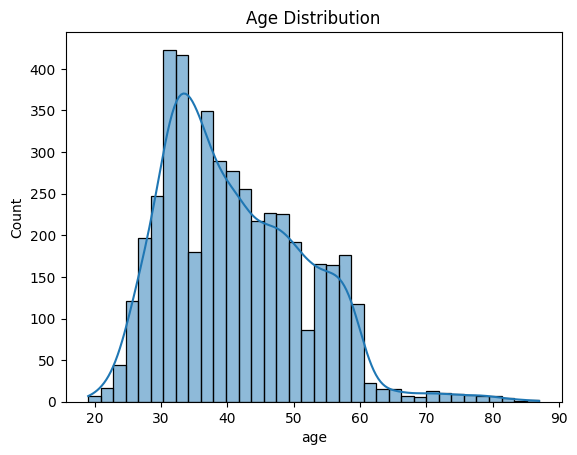

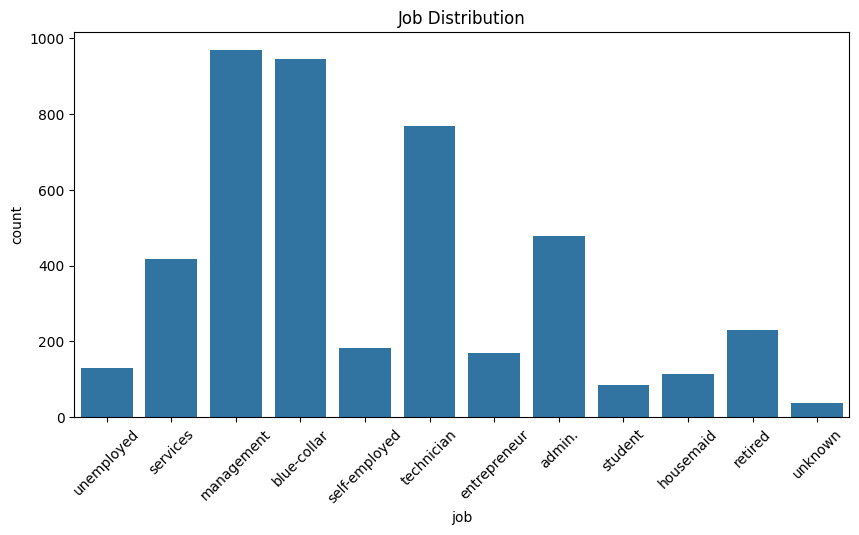

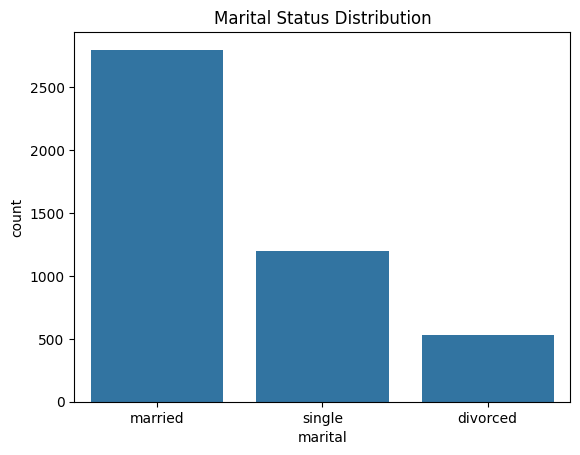


Accuracy: 0.8939226519337017

Confusion Matrix:
 [[791  16]
 [ 80  18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94       807
           1       0.53      0.18      0.27        98

    accuracy                           0.89       905
   macro avg       0.72      0.58      0.61       905
weighted avg       0.87      0.89      0.87       905



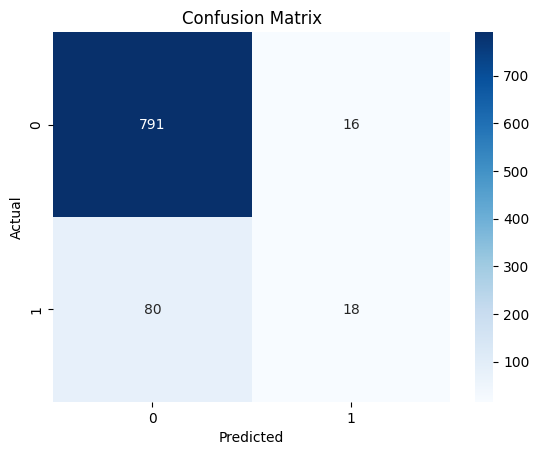

In [4]:
# ==========================================
# TASK 5: PERSONAL LOAN ACCEPTANCE PREDICTION
# DevelopersHub Internship
# ==========================================

# ---------------- IMPORT LIBRARIES ----------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------- LOAD DATASET ----------------
df = pd.read_csv("bank.csv", sep=';')

# ---------------- BASIC INFO ----------------
print("Shape:", df.shape)
print(df.head())
print(df.info())

# ---------------- MISSING VALUES CHECK ----------------
print("Missing Values:\n", df.isnull().sum())

# ---------------- EDA VISUALIZATION ----------------

plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x='job', data=df)
plt.xticks(rotation=45)
plt.title("Job Distribution")
plt.show()

plt.figure()
sns.countplot(x='marital', data=df)
plt.title("Marital Status Distribution")
plt.show()

# ---------------- DATA PREPROCESSING ----------------
le = LabelEncoder()

# Encode all categorical columns safely
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# ---------------- SPLIT DATA ----------------
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- FEATURE SCALING  ----------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------- MODEL TRAINING ----------------
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

# ---------------- PREDICTION ----------------
y_pred = model.predict(X_test)

# ---------------- EVALUATION ----------------
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---------------- CONFUSION MATRIX VISUALIZATION ----------------
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()